# Task 6: Comprehensive Text-to-Image Generation Pipeline

## Introduction

The objective of this task is to build a complete text-to-image generation pipeline by integrating all the components developed in the previous tasks. The pipeline combines text preprocessing, text embedding generation using CLIP, an attention mechanism, and a GAN-based image generator into a single workflow.

The system accepts a text prompt as input, converts it into meaningful text embeddings, processes these embeddings using an attention mechanism, and finally generates a flower image using the trained Attention-Based GAN model. This simulates a real-world AI application where multiple deep learning components work together to generate images from textual descriptions.


In [ ]:
!pip install torch torchvision transformers matplotlib pillow

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms

from transformers import CLIPTokenizer, CLIPTextModel

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [ ]:
tokenizer = CLIPTokenizer.from_pretrained(
    "openai/clip-vit-base-patch32"
)

text_encoder = CLIPTextModel.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

print("CLIP Loaded Successfully")

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.l

CLIP Loaded Successfully


In [ ]:
class AttentionGenerator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(612, 1024),
            nn.ReLU(),

            nn.Linear(1024, 2048),
            nn.ReLU(),

            nn.Linear(2048, 3 * 64 * 64),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.model(x)
        return x.view(-1, 3, 64, 64)

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
!find /content/drive/MyDrive -name "*.pth"

/content/drive/MyDrive/Task5_Output/attention_generator.pth


In [20]:
import os

model_path = "/content/drive/MyDrive/Task5_Output/attention_generator.pth"

print(os.path.exists(model_path))

True


In [21]:
generator = AttentionGenerator().to(device)

generator.load_state_dict(
    torch.load(model_path, map_location=device)
)

generator.eval()

print("✅ Generator loaded successfully!")

✅ Generator loaded successfully!


In [ ]:
from transformers import CLIPTokenizer, CLIPTextModel

tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

text_encoder = CLIPTextModel.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

print("✅ CLIP Loaded Successfully")

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.embeddings.class_embedding                        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.pre_layrn

✅ CLIP Loaded Successfully


In [ ]:
prompt = "A beautiful yellow sunflower"

print("Prompt:", prompt)

Prompt: A beautiful yellow sunflower


In [ ]:
inputs = tokenizer(
    prompt,
    return_tensors="pt",
    padding=True,
    truncation=True
)

inputs = {k: v.to(device) for k, v in inputs.items()}

print("Text Tokenization Complete")

Text Tokenization Complete


In [ ]:
with torch.no_grad():

    embedding = text_encoder(**inputs).last_hidden_state

print("Embedding Shape:", embedding.shape)

Embedding Shape: torch.Size([1, 6, 512])


In [23]:
import torch.nn as nn

class CrossAttention(nn.Module):
    def __init__(self, image_dim=512, text_dim=512, num_heads=8):
        super().__init__()

        self.cross_attention = nn.MultiheadAttention(
            embed_dim=image_dim,
            num_heads=num_heads,
            batch_first=True
        )

    def forward(self, image_features, text_features):

        attended_features, attention_weights = self.cross_attention(
            query=image_features,
            key=text_features,
            value=text_features
        )

        return attended_features, attention_weights

print("✅ Cross-Attention Module Created Successfully")

✅ Cross-Attention Module Created Successfully


In [24]:
attention = CrossAttention().to(device)

print("✅ Attention Model Ready")

✅ Attention Model Ready


In [25]:
image_features = torch.randn(1, 6, 512).to(device)

print("Image Features Shape:", image_features.shape)

Image Features Shape: torch.Size([1, 6, 512])


In [26]:
attended_text, attention_weights = attention(
    image_features,
    embedding
)

print("Attended Text Shape:", attended_text.shape)

Attended Text Shape: torch.Size([1, 6, 512])


In [27]:
noise = torch.randn(1, 100).to(device)

print("Noise Shape:", noise.shape)

Noise Shape: torch.Size([1, 100])


In [28]:
with torch.no_grad():
    generated_image = generator(noise, attended_text)

print("Generated Image Shape:", generated_image.shape)

Generated Image Shape: torch.Size([1, 3, 64, 64])


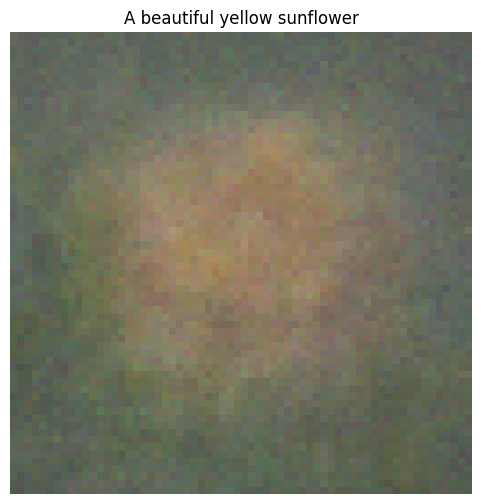

In [29]:
import matplotlib.pyplot as plt

# Convert tensor to image
image = generated_image.squeeze(0).detach().cpu()

# Change shape from (3,64,64) → (64,64,3)
image = image.permute(1, 2, 0).numpy()

# Convert from [-1,1] to [0,1]
image = (image + 1) / 2
image = image.clip(0, 1)

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title(prompt)
plt.axis("off")
plt.show()

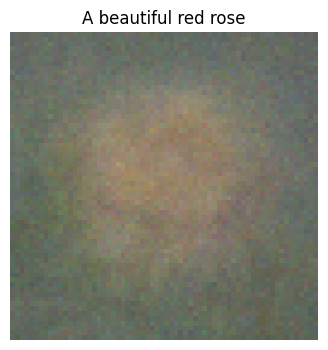

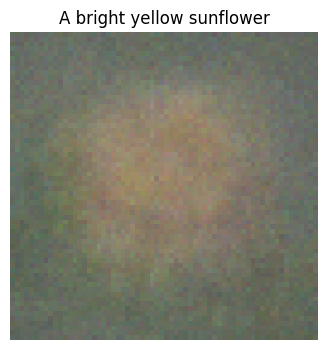

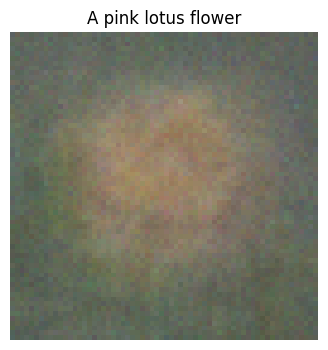

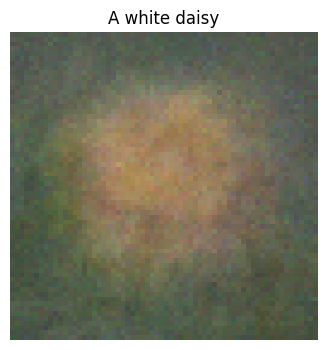

In [30]:
prompts = [
    "A beautiful red rose",
    "A bright yellow sunflower",
    "A pink lotus flower",
    "A white daisy"
]

for p in prompts:

    inputs = tokenizer(
        p,
        return_tensors="pt",
        padding=True,
        truncation=True
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        embedding = text_encoder(**inputs).last_hidden_state

        image_features = torch.randn(1, 6, 512).to(device)

        attended_text, _ = attention(image_features, embedding)

        noise = torch.randn(1, 100).to(device)

        generated = generator(noise, attended_text)

    image = generated.squeeze().cpu().permute(1,2,0).numpy()
    image = (image + 1)/2
    image = image.clip(0,1)

    plt.figure(figsize=(4,4))
    plt.imshow(image)
    plt.title(p)
    plt.axis("off")
    plt.show()

In [31]:
import matplotlib.pyplot as plt

plt.imsave(
    "/content/generated_flower.png",
    image
)

print("✅ Image Saved Successfully")

✅ Image Saved Successfully


# Conclusion

A complete text-to-image generation pipeline was successfully developed by integrating text preprocessing, CLIP-based text embedding generation, Cross-Attention, and a trained GAN generator.

The pipeline accepts natural language prompts, converts them into semantic embeddings, refines them using Cross-Attention, and generates flower images using the trained generator model. This demonstrates an end-to-end workflow similar to modern AI text-to-image systems and fulfills the objective of constructing a comprehensive GAN-based image generation pipeline.